In [ ]:
!pip install xgboost imbalanced-learn scikit-learn pandas numpy matplotlib seaborn --quiet

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve
)

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

print("Libraries loaded successfully")

Libraries loaded successfully


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving df_injury_player_data_features_v1.csv to df_injury_player_data_features_v1.csv


In [ ]:
df = pd.read_csv("df_injury_player_data_features_v1.csv")

print("Shape:", df.shape)
display(df.head())

print("\nColumns:")
for col in df.columns:
    print(col)

Shape: (1301, 30)


,p_id2,start_year,season_days_injured,total_days_injured,season_minutes_played,season_games_played,season_matches_in_squad,total_minutes_played,total_games_played,dob,...,cumulative_games_played,minutes_per_game_prev_seasons,avg_days_injured_prev_seasons,avg_games_per_season_prev_seasons,bmi,work_rate_numeric,position_numeric,significant_injury_prev_season,cumulative_days_injured,season_days_injured_prev_season
0,aaronconnolly,2019,13,161,1312.0,24,28,2148.0,41,2000-01-28,...,NaN,NaN,NaN,NaN,24.613627,2.5,2.0,NaN,NaN,NaN
1,aaronconnolly,2020,71,161,836.0,17,28,2148.0,41,2000-01-28,...,24.0,54.666667,13.0,24.0,24.613627,2.5,2.0,0.0,161.0,13.0
2,aaroncresswell,2016,95,226,2247.0,26,27,13368.0,149,1989-12-15,...,NaN,NaN,NaN,NaN,22.396079,3.5,1.0,NaN,NaN,NaN
3,aaroncresswell,2018,87,226,1680.0,20,27,13368.0,149,1989-12-15,...,26.0,86.423077,95.0,26.0,22.396079,3.5,1.0,0.0,226.0,95.0
4,aaroncresswell,2019,35,226,2870.0,31,31,13368.0,149,1989-12-15,...,46.0,85.369565,91.0,23.0,22.396079,3.5,1.0,0.0,452.0,87.0



Columns:
p_id2
start_year
season_days_injured
total_days_injured
season_minutes_played
season_games_played
season_matches_in_squad
total_minutes_played
total_games_played
dob
height_cm
weight_kg
nationality
work_rate
pace
physic
fifa_rating
position
age
cumulative_minutes_played
cumulative_games_played
minutes_per_game_prev_seasons
avg_days_injured_prev_seasons
avg_games_per_season_prev_seasons
bmi
work_rate_numeric
position_numeric
significant_injury_prev_season
cumulative_days_injured
season_days_injured_prev_season


In [ ]:
DAYS_COL = "season_days_injured"

df["target_major_injury"] = (
    df[DAYS_COL] > 120
).astype(int)

print(df["target_major_injury"].value_counts())

target_major_injury
0    1029
1     272
Name: count, dtype: int64


In [ ]:
df = df.dropna(subset=[DAYS_COL])

In [ ]:
exclude_cols = [
    "target_major_injury",
    "season_days_injured",
    "p_id2"
]

FEATURE_COLS = []

for col in df.columns:

    if col in exclude_cols:
        continue

    if pd.api.types.is_numeric_dtype(df[col]):
        FEATURE_COLS.append(col)

print("Number of features:", len(FEATURE_COLS))
print(FEATURE_COLS)

Number of features: 24
['start_year', 'total_days_injured', 'season_minutes_played', 'season_games_played', 'season_matches_in_squad', 'total_minutes_played', 'total_games_played', 'height_cm', 'weight_kg', 'pace', 'physic', 'fifa_rating', 'age', 'cumulative_minutes_played', 'cumulative_games_played', 'minutes_per_game_prev_seasons', 'avg_days_injured_prev_seasons', 'avg_games_per_season_prev_seasons', 'bmi', 'work_rate_numeric', 'position_numeric', 'significant_injury_prev_season', 'cumulative_days_injured', 'season_days_injured_prev_season']


In [ ]:
X = df[FEATURE_COLS].copy()

X = X.fillna(X.median())

y = df["target_major_injury"]

print(X.shape)
print(y.shape)

(1301, 24)
(1301,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

Train shape: (910, 24)
Test shape : (391, 24)


In [ ]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE")
print(y_train.value_counts())

print("\nAfter SMOTE")
print(pd.Series(y_train_smote).value_counts())

Before SMOTE
target_major_injury
0    720
1    190
Name: count, dtype: int64

After SMOTE
target_major_injury
0    720
1    720
Name: count, dtype: int64


In [ ]:
model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    min_child_weight=1,
    colsample_bytree=0.8,
    subsample=0.9,
    eval_metric="logloss",
    random_state=42
)

model.fit(
    X_train_smote,
    y_train_smote
)

print("Model trained successfully")

Model trained successfully


In [ ]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]

In [ ]:
acc = accuracy_score(y_test, y_pred)

prec = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

rec = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

auc = roc_auc_score(
    y_test,
    y_prob
)

print("="*50)
print("MODEL PERFORMANCE")
print("="*50)

print("Accuracy :", round(acc,4))
print("Precision:", round(prec,4))
print("Recall   :", round(rec,4))
print("F1 Score :", round(f1,4))
print("AUC ROC  :", round(auc,4))

MODEL PERFORMANCE
Accuracy : 0.8414
Precision: 0.6163
Recall   : 0.6463
F1 Score : 0.631
AUC ROC  : 0.8784


In [ ]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.90      0.89      0.90       309
           1       0.62      0.65      0.63        82

    accuracy                           0.84       391
   macro avg       0.76      0.77      0.76       391
weighted avg       0.84      0.84      0.84       391



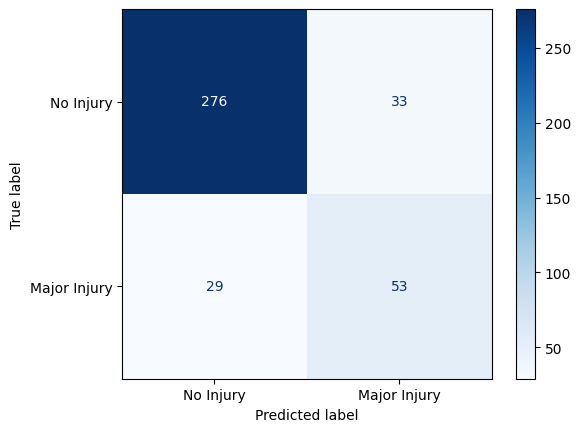

In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "No Injury",
        "Major Injury"
    ]
)

disp.plot(cmap="Blues")

plt.show()

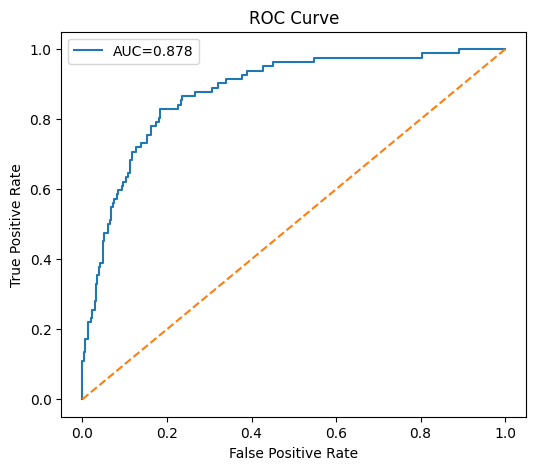

In [ ]:
fpr, tpr, _ = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC={auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    "--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

In [ ]:
importance_df = pd.DataFrame({
    "Feature": FEATURE_COLS,
    "Importance": model.feature_importances_
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

print(importance_df.head(20))

                              Feature  Importance
4             season_matches_in_squad    0.149407
1                  total_days_injured    0.114183
3                 season_games_played    0.104811
19                  work_rate_numeric    0.071254
20                   position_numeric    0.054808
0                          start_year    0.045879
22            cumulative_days_injured    0.033093
5                total_minutes_played    0.032715
17  avg_games_per_season_prev_seasons    0.032703
16      avg_days_injured_prev_seasons    0.031372
2               season_minutes_played    0.028727
14            cumulative_games_played    0.028175
23    season_days_injured_prev_season    0.025976
9                                pace    0.025959
10                             physic    0.025589
11                        fifa_rating    0.024650
15      minutes_per_game_prev_seasons    0.024271
12                                age    0.022854
8                           weight_kg    0.022437


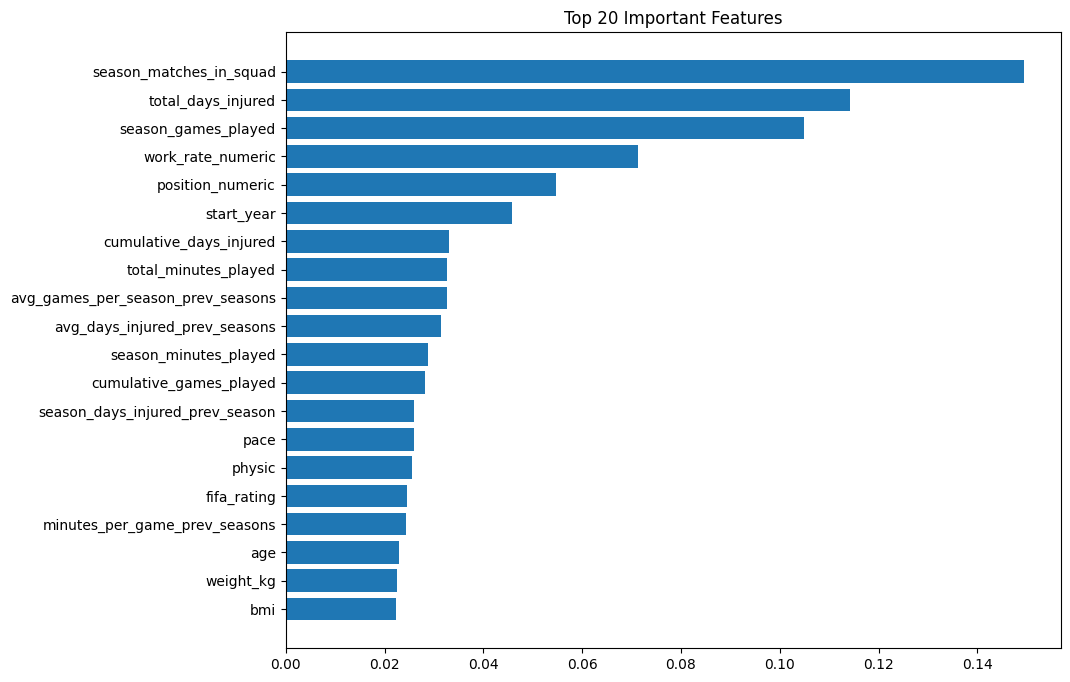

In [ ]:
top20 = importance_df.head(20)

plt.figure(figsize=(10,8))

plt.barh(
    top20["Feature"],
    top20["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 20 Important Features")

plt.show()

In [ ]:
print("Number of features:", len(FEATURE_COLS))

for i, feature in enumerate(FEATURE_COLS, 1):
    print(f"{i}. {feature}")

Number of features: 24
1. start_year
2. total_days_injured
3. season_minutes_played
4. season_games_played
5. season_matches_in_squad
6. total_minutes_played
7. total_games_played
8. height_cm
9. weight_kg
10. pace
11. physic
12. fifa_rating
13. age
14. cumulative_minutes_played
15. cumulative_games_played
16. minutes_per_game_prev_seasons
17. avg_days_injured_prev_seasons
18. avg_games_per_season_prev_seasons
19. bmi
20. work_rate_numeric
21. position_numeric
22. significant_injury_prev_season
23. cumulative_days_injured
24. season_days_injured_prev_season
